In [ ]:
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
import torch
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_MODEL = "bert-base-uncased"

In [23]:
data = pd.read_csv("SPAM text message 20170820 - Data.csv")
data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [24]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
model = AutoModel.from_pretrained(BASE_MODEL)
model

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [25]:
lists_phrases = data.Message.tolist()
model = model.to(device)
model.eval() #Vamos a usar el modelo estático "eval"

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

## Scikit-learn

In [26]:
## Necesita ir por batches ya que el tamaño del dataset puede ser muy grande.
batch_size = 16  #Depende del tamaño de la GPU. 

def get_mean_embeddings(texts, tokenizer, model, device, batch_size=16):
    all_embeddings = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i : i + batch_size]
            inputs = tokenizer(
                batch_texts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=512,
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}

            outputs = model(**inputs)
            embedding = outputs.last_hidden_state
            mask = inputs["attention_mask"].unsqueeze(-1)
            mean_batch = (embedding * mask).sum(dim=1) / mask.sum(dim=1)
            all_embeddings.append(mean_batch.cpu())

    return torch.cat(all_embeddings, dim=0)

mean_embeddings = get_mean_embeddings(
    lists_phrases, tokenizer, model, device, batch_size=batch_size
)
mean_embeddings


tensor([[ 0.0856, -0.5352,  0.5795,  ..., -0.0523,  0.2922, -0.0390],
        [ 0.0742, -0.2921,  0.2895,  ...,  0.1506, -0.0765,  0.0534],
        [ 0.0741, -0.0646,  0.8186,  ..., -0.1393,  0.0246,  0.2203],
        ...,
        [ 0.1639, -0.0519,  0.3487,  ...,  0.0763,  0.0524, -0.0448],
        [ 0.1047, -0.2582,  0.1097,  ..., -0.2214,  0.1068, -0.1445],
        [-0.0686, -0.3453, -0.1142,  ...,  0.0204,  0.4997,  0.2065]])

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [28]:
X = mean_embeddings.detach().cpu().numpy()
y = (data.Category== "spam").astype(int).values #Convertir a numerico

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((4179, 768), (1393, 768), (4179,), (1393,))

In [29]:
# Modelar logistic regression sobre embeddings
parameters = {
    "logistic_regression__C": [0.1, 1],
    "logistic_regression__l1_ratio": [0, 0.5, 1],
}
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=100,
    )),
])
#score = GridSearchCV(pipeline, parameters, cv=5)
#score.fit(X_train, y_train)
#score.best_params_, score.best_score_


## Pytorch

La opción 2 es utilizar sólamente pytorch

In [ ]:
import torch.nn as nn

class TextClassifier(nn.Module):

    def __init__(self, model_name, n_classes):
        super().__init__()

        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.encoder = AutoModel.from_pretrained(model_name)

        for p in self.encoder.parameters():
            p.requires_grad = False
        self.dropout = nn.Dropout(0.5)
        self.classifier = nn.Linear(
            self.encoder.config.hidden_size,
            n_classes
        )

    def forward(self, texts):
        inputs = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            return_tensors="pt"
        )
        inputs = {k: v.to(self.classifier.weight.device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = self.encoder(**inputs)

        hidden = outputs.last_hidden_state
        mask = inputs["attention_mask"].unsqueeze(-1)
        embedding = (hidden * mask).sum(1) / mask.sum(1)
        ## Agregar una capa dropout
        embedding = self.dropout(embedding)
        return self.classifier(embedding)

In [31]:
from sklearn.model_selection import train_test_split

texts = data.Message.tolist()
labels = (data.Category == "spam").astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.25, random_state=42, stratify=labels
)


class SpamDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], int(self.labels[idx])


def collate_fn(batch):
    texts, labels = zip(*batch)
    return list(texts), torch.tensor(labels, dtype=torch.long)


BATCH_SIZE = 32

train_loader = DataLoader(
    SpamDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
)
val_loader = DataLoader(
    SpamDataset(X_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)

len(train_loader), len(val_loader)

(131, 44)

In [32]:
model = TextClassifier(BASE_MODEL, n_classes=2).to(device)
criterion = CrossEntropyLoss()
lr = 1e-3
weight_decay = 0.2
optimizer = AdamW(model.parameters(),
    lr=lr,
    weight_decay=weight_decay)

print(model)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TextClassifier(
  (encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise

In [ ]:
#Simplifying function
def run_epoch(loader, train=True):
    model.train(train)
    total_loss, correct, n = 0.0, 0, 0

    for texts, labels in loader:
        labels = labels.to(device) #Mover a la GPU

        if train: #Backpropagation
            optimizer.zero_grad() #Inicializar en 0 los gradientes

        with torch.set_grad_enabled(train):
            #Evaluar y calcular loss
            logits = model(texts)
            loss = criterion(logits, labels)

        if train: #Backpropagation
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        n += labels.size(0)

    return total_loss / n, correct / n


EPOCHS = 10
PATIENCE = 3
#Usar un json para guardar el historial
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

best_val_loss = float("inf") #We could use a min loss or a max acc
best_loss = None
patience_count = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"epoch {epoch}/{EPOCHS} | "
        f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.3f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_loss = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"Early stopping en epoch {epoch} (mejor val loss: {best_val_loss:.4f})")
            break

if best_loss is not None:
    model.load_state_dict(best_loss)
    print(f"Modelo restaurado al mejor checkpoint (val loss {best_val_loss:.4f})")


epoch 1/10 | train loss 0.1749 acc 0.943 | val loss 0.0793 acc 0.976
epoch 2/10 | train loss 0.0684 acc 0.984 | val loss 0.0606 acc 0.978
epoch 3/10 | train loss 0.0551 acc 0.985 | val loss 0.0524 acc 0.983
epoch 4/10 | train loss 0.0497 acc 0.985 | val loss 0.0497 acc 0.983
epoch 5/10 | train loss 0.0458 acc 0.988 | val loss 0.0471 acc 0.983
epoch 6/10 | train loss 0.0450 acc 0.989 | val loss 0.0461 acc 0.984
epoch 7/10 | train loss 0.0428 acc 0.989 | val loss 0.0449 acc 0.986
epoch 8/10 | train loss 0.0417 acc 0.989 | val loss 0.0441 acc 0.986
epoch 9/10 | train loss 0.0396 acc 0.990 | val loss 0.0449 acc 0.986
epoch 10/10 | train loss 0.0389 acc 0.987 | val loss 0.0446 acc 0.986
Modelo restaurado al mejor checkpoint (val loss 0.0441)


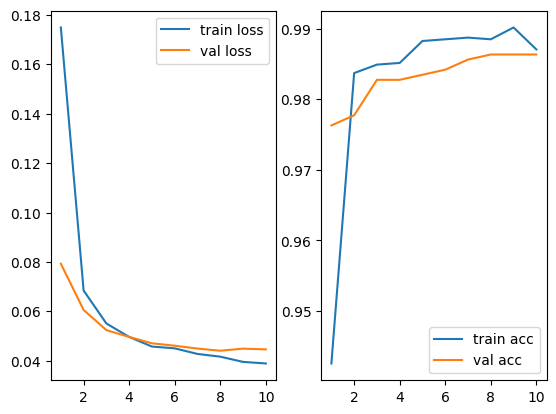

In [44]:
plt.subplot(1, 2, 1)
sns.lineplot(y = history["train_loss"], x = range(1, len(history["train_loss"]) + 1), label = "train loss")
sns.lineplot(y = history["val_loss"], x = range(1, len(history["val_loss"]) + 1), label = "val loss")
plt.subplot(1, 2, 2)
sns.lineplot(y = history["train_acc"], x = range(1, len(history["train_acc"]) + 1), label = "train acc")
sns.lineplot(y = history["val_acc"], x = range(1, len(history["val_acc"]) + 1), label = "val acc")
plt.show()

In [36]:
# Prueba rapida con mensajes nuevos
examples = [
    "Congratulations! You won a FREE iPhone. Call now to claim your prize!",
    "Hello, how are you?",
]

model.eval()
with torch.no_grad():
    logits = model(examples)
    preds = logits.argmax(dim=1).tolist()

for text, pred in zip(examples, preds):
    label = "spam" if pred == 1 else "ham"
    print(f"[{label}] {text}")

[spam] Congratulations! You won a FREE iPhone. Call now to claim your prize!
[ham] Hello, how are you?
